In [1]:
import numpy as np
import pandas as pd
import pywt
from pywt import WaveletPacket
import os

# -------- INPUTS --------
file_path = './PV.csv' 
target_col = 'GHI'
datetime_col = 'DateTime'
output_path = './'
wavelet = 'db8'
maxlevel = 2

# -------- LOAD DATA --------
df = pd.read_csv(file_path, parse_dates=[datetime_col])
original_signal = df[target_col].values
datetime_series = df[datetime_col]
original_length = len(original_signal)

In [2]:
# -------- DECOMPOSE AND RECONSTRUCT --------
wp = WaveletPacket(data=original_signal, wavelet=wavelet, mode='symmetric', maxlevel=maxlevel)
sub_signals = {}

for node in wp.get_level(maxlevel, 'natural'):
    path = node.path
    wp_temp = WaveletPacket(data=np.zeros(original_length), wavelet=wavelet, mode='symmetric')
    wp_temp[path] = node.data
    rec = wp_temp.reconstruct(update=False)

    rec = rec[:original_length] if len(rec) > original_length else np.pad(rec, (0, original_length - len(rec)), 'constant')
    sub_signals[path] = rec

# -------- SAVE TO SINGLE CSV --------
result_df = pd.DataFrame({datetime_col: datetime_series})
for path, signal in sub_signals.items():
    result_df[f'SS_{path}'] = signal

# result_df.to_csv(output_path, index=False)

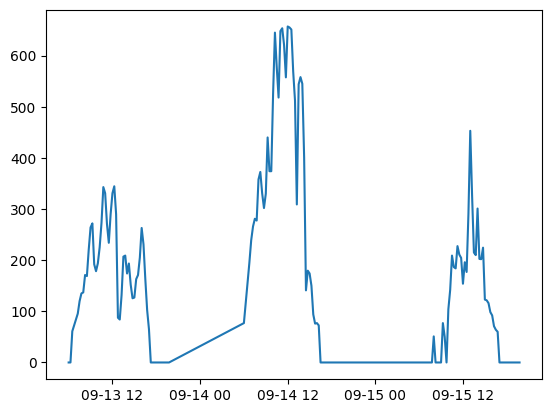

In [28]:
import matplotlib.pyplot as plt
DAY = 12

plt.plot(df[datetime_col][DAY*56:(DAY+3)*56], df['GHI'][DAY*56:(DAY+3)*56], label='Approximation Coefficients')

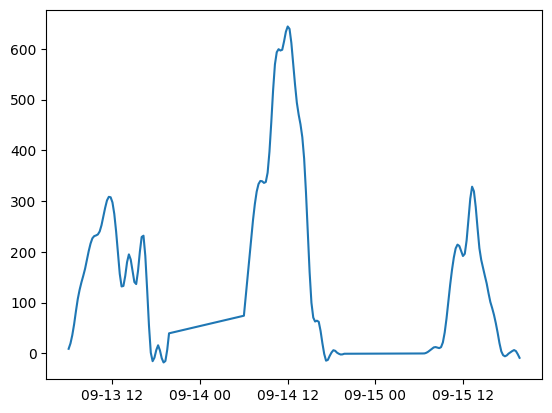

In [29]:

plt.plot(result_df[datetime_col][DAY*56:(DAY+3)*56], result_df['SS_aa'][DAY*56:(DAY+3)*56], label='Approximation Coefficients')

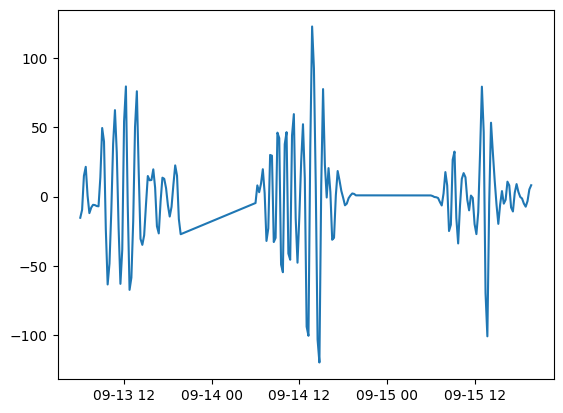

In [30]:
plt.plot(result_df[datetime_col][DAY*56:(DAY+3)*56], result_df['SS_ad'][DAY*56:(DAY+3)*56], label='Approximation Coefficients')

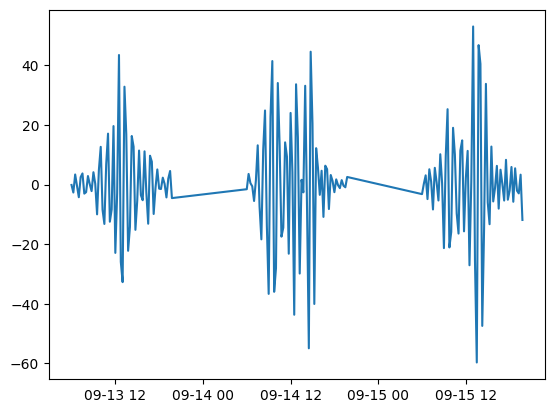

In [31]:
plt.plot(result_df[datetime_col][DAY*56:(DAY+3)*56], result_df['SS_dd'][DAY*56:(DAY+3)*56], label='Approximation Coefficients')

In [57]:
result_df

,DateTime,SS_aa,SS_ad,SS_da,SS_dd
0,2021-09-01 06:00:00,-7.760820,10.339132,2.990150,-5.568462
1,2021-09-01 06:15:00,-3.703838,2.200502,-0.507680,2.011016
2,2021-09-01 06:30:00,3.271490,-9.074811,-2.640928,8.444249
3,2021-09-01 06:45:00,12.599708,-13.950302,6.208235,-4.857641
4,2021-09-01 07:00:00,23.769819,-6.428979,-8.854113,-8.486728
...,...,...,...,...,...
44291,2023-10-31 18:45:00,-0.274935,0.274935,-0.109224,0.109224
44292,2023-10-31 19:00:00,-0.122399,0.122399,0.256888,-0.256888
44293,2023-10-31 19:15:00,0.002666,-0.002666,-0.182624,0.182624
44294,2023-10-31 19:30:00,0.060766,-0.060766,0.009457,-0.009457


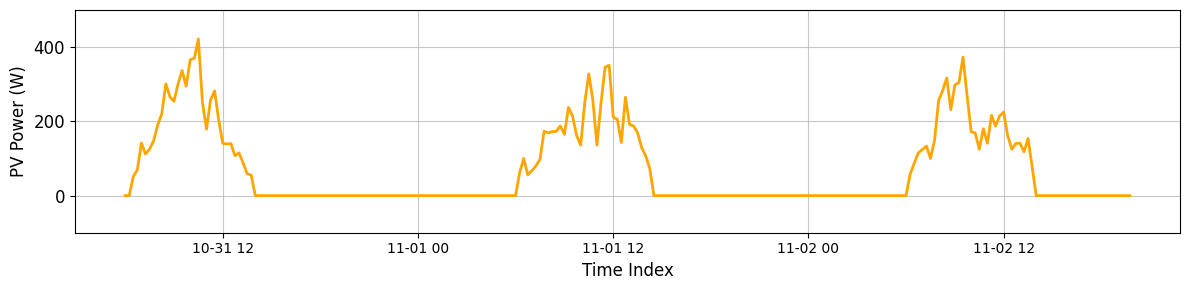

In [104]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Simulated data for illustration purposes
DAY = 60  # Adjust as needed

# Create the plot
plt.figure(figsize=(12, 3))

# Plotting the lines
plt.plot(df[datetime_col][DAY*56:(DAY+3)*56], df['GHI'][DAY*56:(DAY+3)*56], label='Approximation Coefficients', linewidth=2, color='orange')

# Add labels and title
plt.xlabel('Time Index', fontsize=12)
plt.ylabel('PV Power (W)', fontsize=12)
#plt.title('Forecasting Results for Specific Period')
plt.ylim([-100, 500])
# Rotate x-axis labels to avoid overlap
# plt.xticks(data['DateTime'][::8], rotation=45, fontsize=12)
plt.yticks([0, 200, 400], fontsize=12)
# Add grid
plt.grid(True, alpha=0.7)

# Show the plot
plt.tight_layout()
plt.savefig(f'in.png', dpi=300, pad_inches=0)




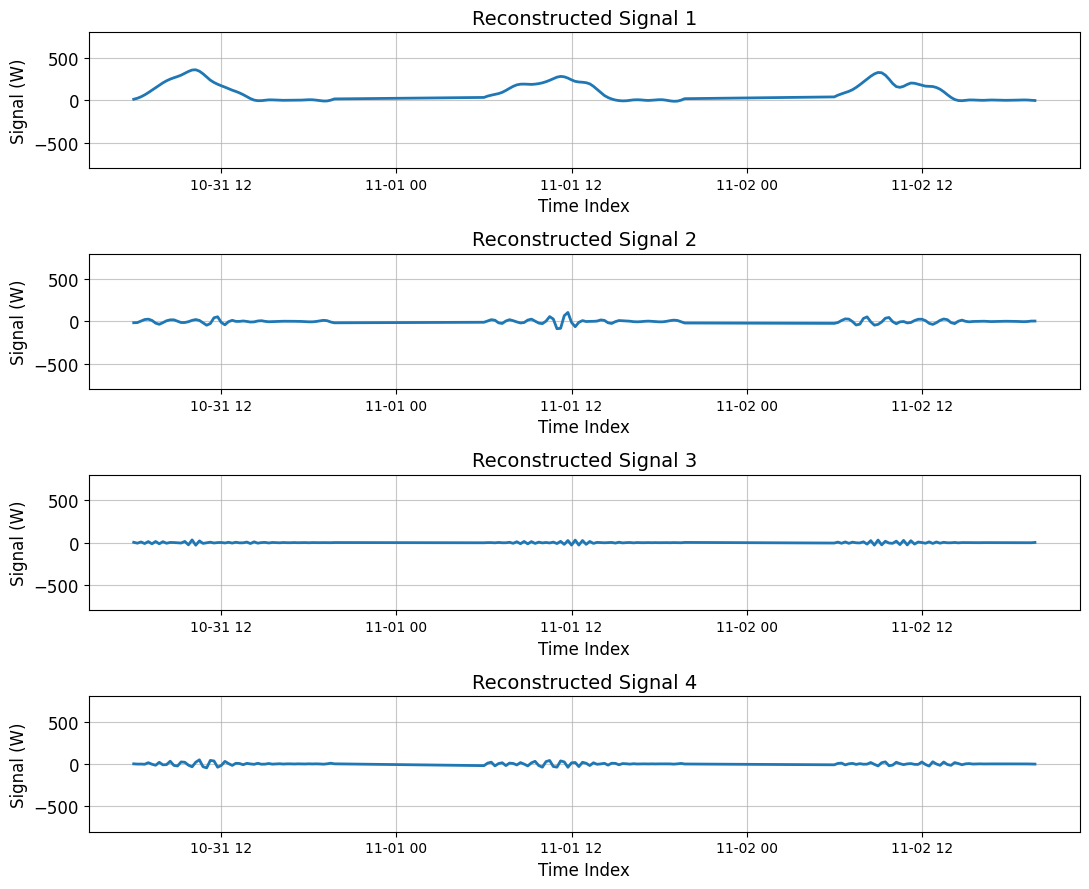

In [109]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from uuid import uuid4

# Parameters
labels = ['SS_aa', 'SS_ad', 'SS_da', 'SS_dd']
titles = ['Reconstructed Signal 1', 'Reconstructed Signal 2', 'Reconstructed Signal 3', 'Reconstructed Signal 4']

# Create the subplot
plt.figure(figsize=(11, 9))

for i, (label, title) in enumerate(zip(labels, titles), 1):
    plt.subplot(4, 1, i)
    plt.plot(result_df[datetime_col][DAY*56:(DAY+3)*56], 
             result_df[label][DAY*56:(DAY+3)*56], 
             linewidth=2)
    
    # Add labels and title
    plt.title(title, fontsize=14)
    plt.xlabel('Time Index', fontsize=12)
    plt.ylabel('Signal (W)', fontsize=12)
    plt.ylim([-800, 800])
    plt.yticks([-500, 0, 500], fontsize=12)
        
    # Add grid
    plt.grid(True, alpha=0.7)
    
    # Add legend
    # plt.legend()

# Adjust layout to prevent overlap
plt.tight_layout()

# Save the plot
plt.savefig(f'subplot_4x1_{uuid4()}.png', dpi=300, pad_inches=0)